# Preamble

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections
import csv
import pickle
import seaborn as sns
from simulation import ln_cells
from utils import augment_sample
import pandas as pd
from matplotlib.gridspec import GridSpec
import scipy
from ode_dynamics import ln_dynamics
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"], # or ["cmr10"]
})


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\gaier\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

# Trajectories

(-5.0, 66.0)

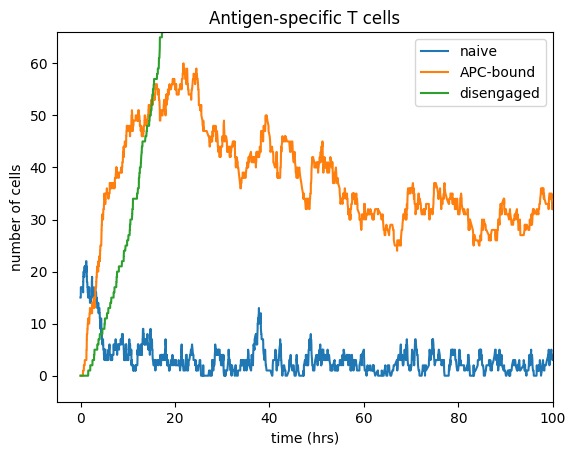

In [31]:
simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
n_steps=3000
container=np.zeros((3,n_steps))
t=np.zeros(n_steps)
for i in range(n_steps):
    simulation.step()
    container[0,i]=np.sum(simulation.interacting)
    container[1,i]=simulation.n_naive_free
    container[2,i]=simulation.n_active
    t[i]=simulation.t

fig,ax=plt.subplots()
ax.plot(t,container[1],label='naive')
ax.plot(t,container[0],label='APC-bound')
ax.plot(t,container[2],label='disengaged')
ax.legend()
ax.set_xlabel('time (hrs)')
ax.set_ylabel('number of cells')
ax.set_title('Antigen-specific T cells')
ax.set_xlim(-5,100)
ax.set_ylim(-5,np.amax(container[:2])*1.1)

(-5.0, 75.0)

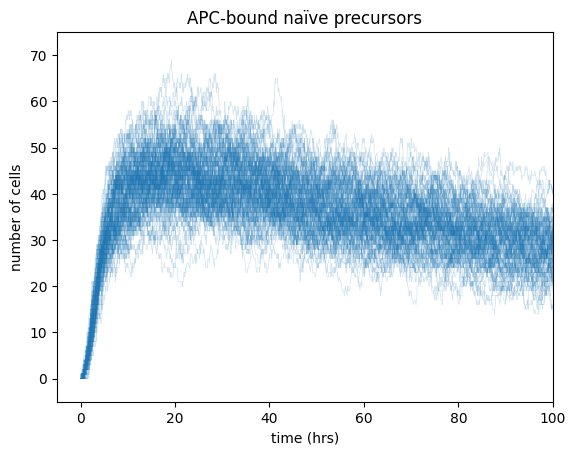

In [34]:
fig,ax=plt.subplots()
for _ in range(100):
    simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
    n_steps=3000
    container=np.zeros((3,n_steps))
    t=np.zeros(n_steps)
    for i in range(n_steps):
        simulation.step()
        container[0,i]=np.sum(simulation.interacting)
        container[1,i]=simulation.n_naive_free
        container[2,i]=simulation.n_active
        t[i]=simulation.t
    ax.plot(t,container[0],label='APC-bound',c='C0',alpha=0.2,linewidth=0.5)

# ax.legend()
ax.set_xlabel('time (hrs)')
ax.set_ylabel('number of cells')
ax.set_title('APC-bound naïve precursors')
ax.set_xlim(-5,100)
ax.set_ylim(-5,75)

(-5.0, 75.0)

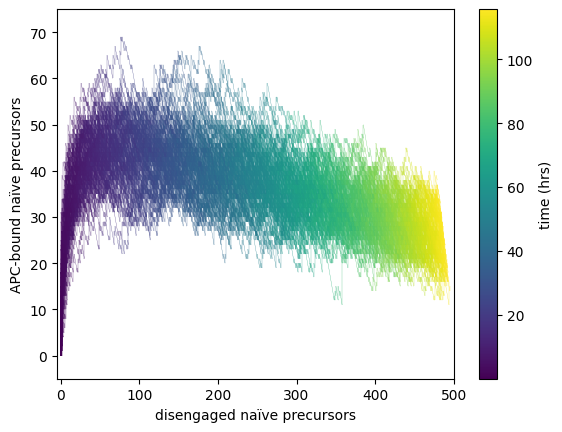

In [54]:
fig,ax=plt.subplots()
for _ in range(100):
    simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
    n_steps=3000
    container=np.zeros((3,n_steps))
    t=np.zeros(n_steps)
    for i in range(n_steps):
        simulation.step()
        container[0,i]=np.sum(simulation.interacting)
        container[1,i]=simulation.n_naive_free
        container[2,i]=simulation.n_active
        t[i]=simulation.t
    points = container[[2,0]].transpose().reshape(-1,1,2)
    # set up a list of segments
    segs = np.concatenate([points[:-1],points[1:]],axis=1)

    # make the collection of segments
    lc = matplotlib.collections.LineCollection(segs, cmap=plt.get_cmap('viridis'),linewidth=0.2)
    lc.set_array(t) # color the segments by our parameter

    # plot the collection
    ax.add_collection(lc)
    # ax.scatter(container[2],container[0],c=t,alpha=0.2,s=2)

# ax.legend()
ax.set_xlabel('disengaged naïve precursors')
ax.set_ylabel('APC-bound naïve precursors')
fig.colorbar(lc,label='time (hrs)')
ax.set_xlim(-5,500)
ax.set_ylim(-5,75)

In [42]:
container[[2,0]]

array([[  0.,   0.,   0., ..., 487., 488., 488.],
       [  0.,   0.,   0., ...,  26.,  25.,  25.]], shape=(2, 3000))

In [6]:
n_runs=1000
dist_cont=np.zeros(n_runs)
for j in range(n_runs):
    simulation=ln_cells(n_apc=100,diffusivity=1000,mode='Mandl',recruit_fact=5)
    n_steps=1500
    max_container=np.zeros(n_steps)
    t=np.zeros(n_steps)
    for i in range(n_steps):
        simulation.step()
        max_container[i]=np.amax(simulation.interacting)
    dist_cont[j]=np.amax(max_container)



Text(0, 0.5, 'simulation count')

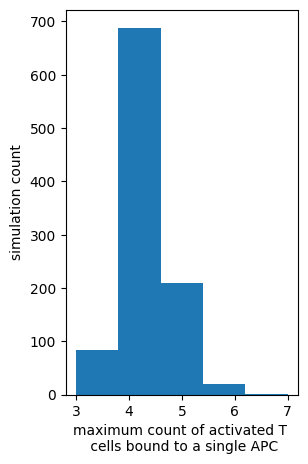

In [12]:
fig,ax=plt.subplots(figsize=(3,5))
ax.hist(dist_cont,bins=5)
# ax.legend()
ax.set_xlabel('maximum count of activated T \n cells bound to a single APC')
ax.set_ylabel('simulation count')


# Comparison vs invivo

In [3]:
with open('240730_processed_export.pickle','rb') as f:
    exports=pickle.load(f)

In [4]:
for key,value in exports.items():
    print(key,len(value))

1L2_Th 21700
1L2_mAPC 209
1L2_Th_mAPC_dist 21700
1R2_Th 14923
1R2_mAPC 245
1R2_Th_mAPC_dist 14923
2L2_Th 15587
2L2_mAPC 203
2L2_Th_mAPC_dist 15587
2R2_Th 14852
2R2_mAPC 263
2R2_Th_mAPC_dist 14852


In [5]:
def condition(sample):
    if 'L' in sample:
        return 'KLH'
    elif 'R' in sample:
        return 'OVA'
    else:
        raise RuntimeError('Unknown condition')
    
samples=['1L2','1R2','2L2','2R2']
gfp_hi_thresh=1.
gfp_lo_thresh=0.1

Text(0, 0.5, 'number of GFP hi CD4 Tconv within 40um')

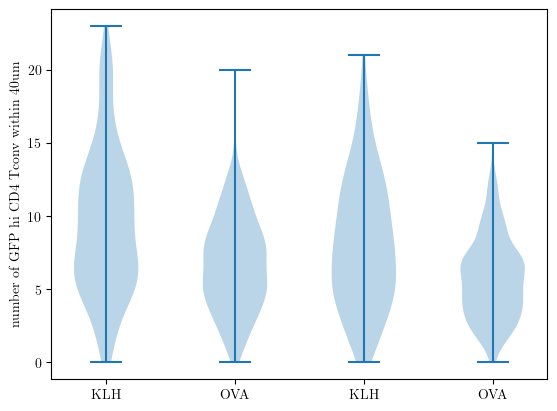

In [6]:
plot_data=[]
max_dist=40
for sample in samples:
    plot_data.append(((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0))
plt.violinplot(plot_data)

plt.xticks(np.arange(1,5),['KLH','OVA','KLH','OVA'])
plt.ylabel('number of GFP hi CD4 Tconv within 40um')

simulation: distribution of naive cells localized to APC
for each APC:
1. sample from distribution (can parallelize)
2. pick co-localized GFPlo CD4 T cell and turn on GFP (this will modify the mask)

In [7]:
simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
n_steps=1500
while simulation.t<48:
    simulation.step()

KeyError: 'Unknown estimation mode for k_2'

In [ ]:
simulation.interacting.sum()+simulation.n_naive_free+simulation.n_active

np.float64(246.0)

In [ ]:
simulation.interacting

array([0., 0., 0., ..., 0., 0., 0.], shape=(1500,))

In [ ]:
simulation.n_ln_apc

1492

Text(0.5, 0, 'bound precursors at $t$=48h')

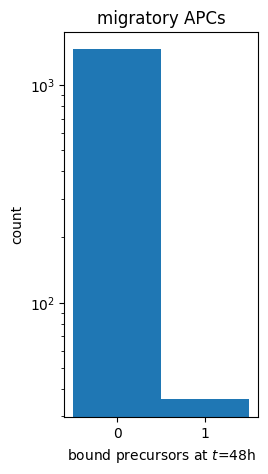

In [ ]:
fig,ax=plt.subplots(figsize=(2.5,5))
ax.hist(simulation.interacting[:simulation.n_ln_apc],bins=[-0.5,0.5,1.5])
ax.set_yscale('log')
ax.set_ylabel('count')
ax.set_title('migratory APCs')
ax.set_xlabel('bound precursors at $t$=48h')

In [ ]:
n_runs=1000
dist_cont=[]
for j in range(n_runs):
    simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
    while simulation.t<48.:
        simulation.step()
    hist,_=np.histogram(simulation.interacting,bins=np.arange(10))
    dist_cont.append(hist)
agg_hist=np.array(dist_cont).sum(axis=0)
# np.random.choice(np.arange(9),size=1000,p=agg_hist/agg_hist.sum())

Text(0.5, 1.0, '1000 simulations')

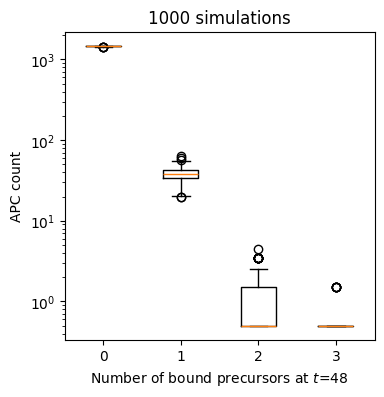

In [ ]:
fig,ax=plt.subplots(figsize=(4,4))
ax.set_yscale('log')
ax.boxplot(np.array(dist_cont)[:,:4]+0.5,positions=range(0,4))
plt.xlabel('Number of bound precursors at $t$=48')
plt.ylabel('APC count')
plt.title('1000 simulations')

In [ ]:
n_runs=1000
dist_cont=[]
data_cont=np.zeros((n_runs,3))
for j in range(n_runs):
    simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
    while simulation.t<48.:
        simulation.step()
    data_cont[j]=np.array([simulation.interacting.sum(),simulation.n_naive_free,simulation.n_active])

In [ ]:
data_cont

array([[ 39.,   1., 228.],
       [ 48.,   2., 227.],
       [ 37.,   2., 223.],
       ...,
       [ 41.,   2., 242.],
       [ 41.,   1., 229.],
       [ 36.,   4., 224.]], shape=(1000, 3))

Text(0.5, 1.0, '1000 simulations; 48 hrs')

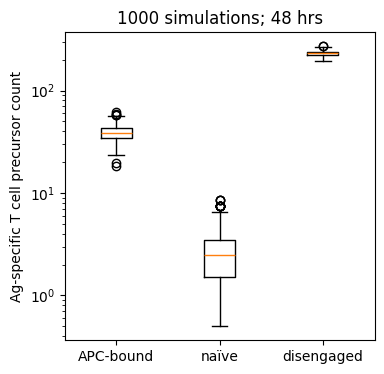

In [ ]:
fig,ax=plt.subplots(figsize=(4,4))
ax.set_yscale('log')
ax.boxplot(data_cont+0.5)
plt.xticks([1,2,3],['APC-bound','naïve','disengaged'])
plt.ylabel('Ag-specific T cell precursor count')
plt.title('1000 simulations; 48 hrs')

In [ ]:
for sample in samples:
    dense_apc_mask=(((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0))>15
    try:
        n_t_cells=(np.min(exports[f'{sample}_Th_mAPC_dist'][:,dense_apc_mask],axis=1)<max_dist).sum()
    except ValueError:
        n_domain=0

2900
336
1403


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
exports[f'{sample}_Th_mAPC_dist'][:,dense_apc_mask]

array([], shape=(14852, 0), dtype=float64)

Text(0.5, 1.0, 'migratory APCs')

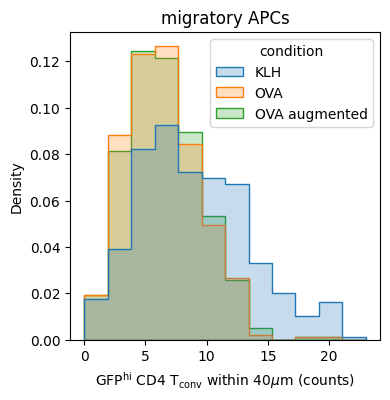

In [ ]:
bound_dist=10
plot_data=[]
max_dist=40

for sample in samples:
    plot_data.append(((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0))
    if condition(sample)=='OVA':
        bound_th=np.int8(np.random.choice(np.arange(9),p=agg_hist/agg_hist.sum(),size=len(exports[f'{sample}_mAPC'])))
        th_gfp_lo_mask=np.array(exports[f'{sample}_Th']['Intensity_Mean_GFP']<gfp_hi_thresh)
        dist_mask=exports[f'{sample}_Th_mAPC_dist']<bound_dist
        for i in np.reshape(np.argwhere(bound_th),-1):
            n_act=bound_th[i]
            try: 
                th_gfp_lo_mask[np.random.choice(np.reshape(np.argwhere(dist_mask[:,i]*th_gfp_lo_mask),-1),size=n_act)]=0
            except ValueError:
                print(i)
        plot_data.append(((exports[f'{sample}_Th_mAPC_dist'][~th_gfp_lo_mask])<max_dist).sum(axis=0))

arr_lst=[(0,3),(1,4),(2,5)]
plot_data=[pd.DataFrame(np.concatenate([plot_data[j] for j in arr_lst[i]])).assign(condition=cond) for i,cond in enumerate(['KLH','OVA','OVA augmented'])]
# plot_data[0]['condition']='OVA'
# plot_data[1]['condition']='KLH'

plot_data=pd.concat(plot_data)
fig,ax=plt.subplots(figsize=(4,4))
sns.histplot(data=plot_data,x=0,ax=ax,hue='condition',stat='density',common_norm=False,element='step',binwidth=2)
ax.set_xlabel('GFP$^\mathrm{hi}$ CD4 T$_\mathrm{conv}$ within 40$\mu$m (counts)')
ax.set_title('migratory APCs')



Text(0.5, 1.0, 'migratory APCs')

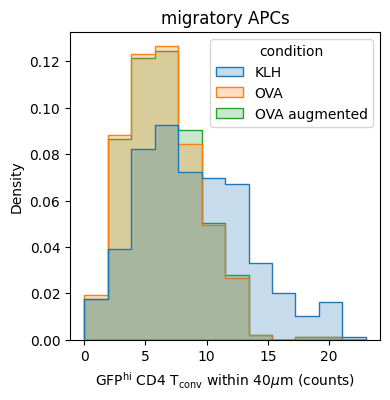

In [ ]:
bound_dist=10
plot_data=[]
max_dist=40

for sample in samples:
    plot_data.append(((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0))
    if condition(sample)=='OVA':
        aug_th_gfp_hi_mask=augment_sample(exports[f'{sample}_Th_mAPC_dist'],np.array(exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh),bound_dist,agg_hist/agg_hist.sum())
        plot_data.append(((exports[f'{sample}_Th_mAPC_dist'][aug_th_gfp_hi_mask])<max_dist).sum(axis=0))

arr_lst=[(0,3),(1,4),(2,5)]
plot_data=[pd.DataFrame(np.concatenate([plot_data[j] for j in arr_lst[i]])).assign(condition=cond) for i,cond in enumerate(['KLH','OVA','OVA augmented'])]
# plot_data[0]['condition']='OVA'
# plot_data[1]['condition']='KLH'

plot_data=pd.concat(plot_data)
fig,ax=plt.subplots(figsize=(4,4))
sns.histplot(data=plot_data,x=0,ax=ax,hue='condition',stat='density',common_norm=False,element='step',binwidth=2)
ax.set_xlabel('GFP$^\mathrm{hi}$ CD4 T$_\mathrm{conv}$ within 40$\mu$m (counts)')
ax.set_title('migratory APCs')



In [ ]:
sample,condition(sample)

('2R2', 'OVA')

In [ ]:
n_realizations=100
container=np.zeros(n_realizations)
for i in range(n_realizations):
    simulation=ln_cells(diffusivity=1000,mode='Mandl',recruit_fact=5)
    while simulation.t<48:
        simulation.step()
    container[i]=(np.random.choice(simulation.interacting[:simulation.n_ln_apc],size=len(exports[f'{sample}_mAPC']))).sum()

plt.hist(container)

NameError: name 'exports' is not defined

## Old Version

In [ ]:
arrays=[]
with open('proximal_gfp_tconv_count.txt','r',newline='\n') as f:
    reader=csv.reader(f)
    for row in reader:
        print(len(row))
        arrays.append([int(row[i]) for i in range(len(row))])

209
245
203
263


In [ ]:
with open('simulation_48h_interacting.pickle','rb') as f:
    interacting_dist=pickle.load(f)

In [ ]:
interacting_dist

array([0., 1., 2., 0., 0., 0., 0., 0., 1., 0., 2., 0., 0., 1., 0., 1., 0.,
       0., 0., 2., 0., 0., 0., 1., 0., 0., 1., 0., 2., 0., 0., 0., 2., 0.,
       2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
       2., 0., 2., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 2.,
       1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 2., 0., 1., 0., 1., 1., 0.,
       2., 1., 0., 0., 0., 0., 2., 0., 0., 1., 1., 0., 1., 0., 0.])

In [ ]:
dist_klh=np.concatenate((arrays[0],arrays[2]))
dist_ova=np.concatenate((arrays[1],arrays[3]))

In [ ]:
dist_simulation=dist_ova+np.random.choice(interacting_dist,len(dist_ova))

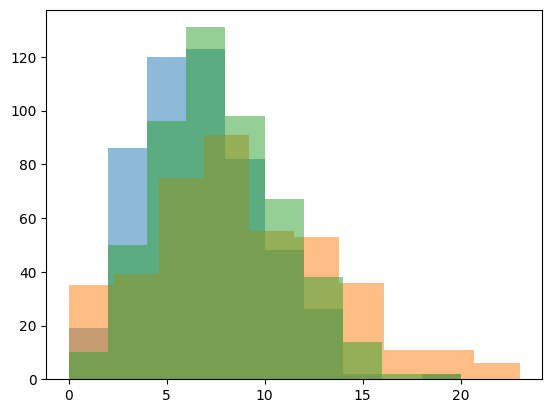

In [ ]:
for arr in [dist_ova,dist_klh,dist_simulation]:
    plt.hist(arr,alpha=0.5)


In [ ]:
with open('density_counts.txt','w',newline='\n') as f:
    writer=csv.writer(f)
    for dist in [dist_ova,dist_klh,dist_simulation]:
        writer.writerow(dist.astype(int))

# Precursor Frequency parameter scan (spatial)

estimates:   
KLH ~20 peptides, 1e-5 to 1e-6  
freq=2e-4 to 2e-5

In [19]:
n_runs=100
n_freqs=10
n_bins=64
freq_cont=np.zeros((n_freqs,n_bins))
for j,freq in enumerate(np.logspace(-6,-3,num=n_freqs)):
    dist_cont=np.zeros((n_runs,n_bins))
    for i in range(n_runs):
        simulation=ln_cells(diffusivity=1000,recruit_fact=5,ag_specific_frequency=freq)
        simulation.step_until(48)
        hist,_=np.histogram(simulation.interacting,bins=np.arange(n_bins+1))
        dist_cont[i]=hist
    agg_hist=np.array(dist_cont).sum(axis=0)
    freq_cont[j]=agg_hist/agg_hist.sum()



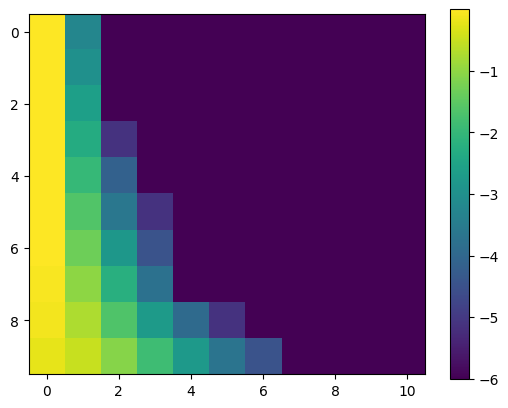

In [27]:
plt.imshow(np.log10(freq_cont+1e-6))
plt.xlim(-0.5,10.5)
plt.colorbar()

In [81]:
n_runs=100
n_freqs=10
n_bins=8
sample='1R2'
bound_dist=10
max_dist=40
n_bins_loc=30
prox_cont=np.zeros((n_freqs,n_bins_loc))
freq_arr=np.logspace(-6,-2.5,num=n_freqs)
for j,freq in enumerate(freq_arr):
    dist_cont=np.zeros((n_runs,n_bins))
    for i in range(n_runs):
        simulation=ln_cells(diffusivity=1000,recruit_fact=5,ag_specific_frequency=freq)
        simulation.step_until(48)
        hist,_=np.histogram(simulation.interacting,bins=np.arange(n_bins+1))
        dist_cont[i]=hist
    agg_hist=np.array(dist_cont).sum(axis=0)
    aug_th_gfp_hi_mask=augment_sample(exports[f'{sample}_Th_mAPC_dist'],np.array(exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh),bound_dist,agg_hist/agg_hist.sum())
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][aug_th_gfp_hi_mask])<max_dist).sum(axis=0)
    prox_cont[j]=np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0]

In [82]:
np.amax(prox_cont)

np.float64(0.13877551020408163)

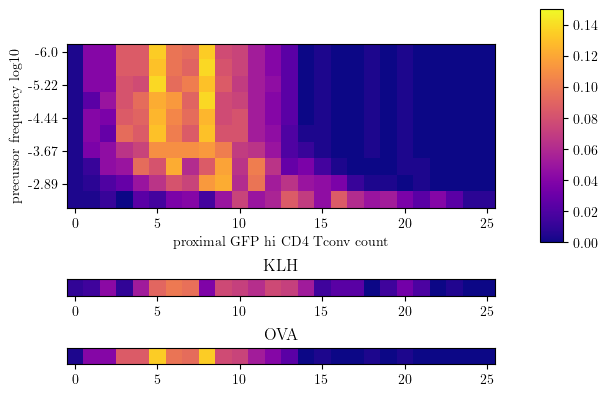

In [88]:
cmap='plasma'
fig=plt.figure()
gs=GridSpec(3,2,width_ratios=[19,1],height_ratios=[5,1,1])
axs=[]
for i in [0,1,2,4]:
    axs.append(fig.add_subplot(gs[i]))
im=axs[0].imshow(prox_cont,vmin=0,vmax=0.15,cmap=cmap)
axs[0].set_xlabel('proximal GFP hi CD4 Tconv count')
axs[0].set_ylabel('precursor frequency log10')
axs[0].set_yticks(np.arange(0,9,2),np.round(np.log10(freq_arr[::2]),2))
for i,sample in ((2,'1L2'),(3,'1R2')):
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
    axs[i].imshow(np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
    axs[i].set_yticks([])
    axs[i].set_title(condition(sample))
for i in [0,2,3]:
    axs[i].set_xlim(-0.5,25.5)
# sample='1R2'
# prox_dist_ova=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
# axs[3].imshow(np.histogram(prox_dist_ova,bins=np.arange(n_bins_loc+1))[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
plt.colorbar(mappable=im,cax=axs[1])

10
17
29
48
81
136
227
378
631
1053


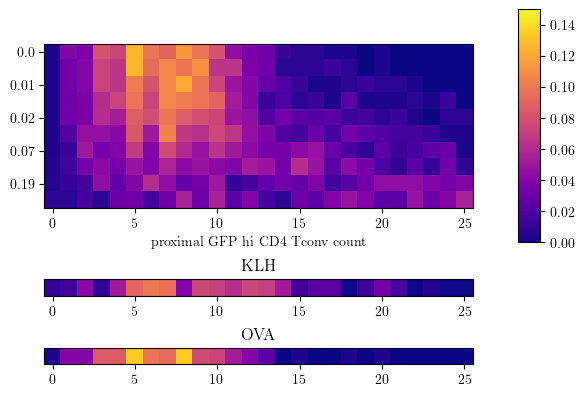

In [39]:
n_runs=100
n_flips=10
n_bins=8
sample='1R2'
bound_dist=10
max_dist=40
n_bins_loc=30
prox_cont=np.zeros((n_flips,n_bins_loc))
flip_arr=np.logspace(-2.5,-0.5,num=n_flips)
candidate_th_mask=(exports[f'{sample}_Th']['Intensity_Mean_GFP']<gfp_hi_thresh) & (exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_lo_thresh)
n_prox_arr=((exports[f'{sample}_Th_mAPC_dist'])<max_dist).sum(axis=1)
idx_arr=np.argsort(n_prox_arr*candidate_th_mask)[::-1]
tot_gfp_on=(exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_lo_thresh).sum()
for j,freq in enumerate(flip_arr):
    aug_th_gfp_hi_mask=exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh
    n_on=np.int64(tot_gfp_on*freq)
    aug_th_gfp_hi_mask[idx_arr[:n_on]]=True    
    print(n_on)
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][aug_th_gfp_hi_mask])<max_dist).sum(axis=0)
    prox_cont[j]=np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0]

prox_cont_gfp_on=prox_cont

cmap='plasma'
fig=plt.figure()
gs=GridSpec(3,2,width_ratios=[19,1],height_ratios=[5,1,1])
axs=[]
for i in [0,1,2,4]:
    axs.append(fig.add_subplot(gs[i]))
im=axs[0].imshow(prox_cont,vmin=0,vmax=0.15,cmap=cmap)
axs[0].set_xlabel('proximal GFP hi CD4 Tconv count')
# axs[0].set_ylabel('precursor frequency log10')
axs[0].set_yticks(np.arange(0,9,2),np.round(flip_arr[::2],2))
for i,sample in ((2,'1L2'),(3,'1R2')):
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
    axs[i].imshow(np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
    axs[i].set_yticks([])
    axs[i].set_title(condition(sample))
for i in [0,2,3]:
    axs[i].set_xlim(-0.5,25.5)
# sample='1R2'
# prox_dist_ova=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
# axs[3].imshow(np.histogram(prox_dist_ova,bins=np.arange(n_bins_loc+1))[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
plt.colorbar(mappable=im,cax=axs[1])

1
3
6
14
32
69
149
321
692
1492


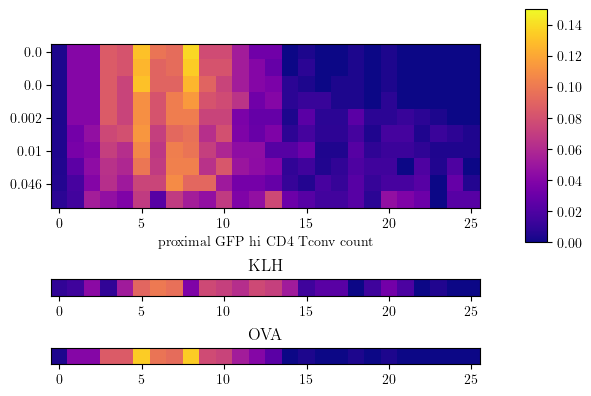

In [40]:
n_runs=100
n_flips=10
n_bins=8
sample='1R2'
bound_dist=10
max_dist=40
n_bins_loc=30
prox_cont=np.zeros((n_flips,n_bins_loc))
flip_arr=np.logspace(-4.0,-1.0,num=n_flips)
candidate_th_mask=(exports[f'{sample}_Th']['Intensity_Mean_GFP']<gfp_hi_thresh)
n_prox_arr=((exports[f'{sample}_Th_mAPC_dist'])<max_dist).sum(axis=1)
idx_arr=np.argsort(n_prox_arr*candidate_th_mask)[::-1]
tot_tconv=len(exports[f'{sample}_Th'])
for j,freq in enumerate(flip_arr):
    aug_th_gfp_hi_mask=exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh
    n_on=np.int64(tot_tconv*freq)
    aug_th_gfp_hi_mask[idx_arr[:n_on]]=True    
    print(n_on)
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][aug_th_gfp_hi_mask])<max_dist).sum(axis=0)
    prox_cont[j]=np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0]

prox_cont_all=prox_cont 

cmap='plasma'
fig=plt.figure()
gs=GridSpec(3,2,width_ratios=[19,1],height_ratios=[5,1,1])
axs=[]
for i in [0,1,2,4]:
    axs.append(fig.add_subplot(gs[i]))
im=axs[0].imshow(prox_cont,vmin=0,vmax=0.15,cmap=cmap)
axs[0].set_xlabel('proximal GFP hi CD4 Tconv count')
# axs[0].set_ylabel('precursor frequency log10')
axs[0].set_yticks(np.arange(0,9,2),np.round(flip_arr[::2],3))
for i,sample in ((2,'1L2'),(3,'1R2')):
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
    axs[i].imshow(np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
    axs[i].set_yticks([])
    axs[i].set_title(condition(sample))
for i in [0,2,3]:
    axs[i].set_xlim(-0.5,25.5)
# sample='1R2'
# prox_dist_ova=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
# axs[3].imshow(np.histogram(prox_dist_ova,bins=np.arange(n_bins_loc+1))[0].reshape((1,-1)),vmin=0,vmax=0.15,cmap=cmap)
plt.colorbar(mappable=im,cax=axs[1])

In [48]:
np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0].reshape((1,-1))[0]

array([0.00408163, 0.04081633, 0.04081633, 0.08571429, 0.08571429,
       0.13469388, 0.09795918, 0.09387755, 0.13469388, 0.07755102,
       0.07346939, 0.05306122, 0.04081633, 0.0244898 , 0.        ,
       0.00408163, 0.        , 0.        , 0.00408163, 0.        ,
       0.00408163, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

Text(0, 0.5, 'frequency')

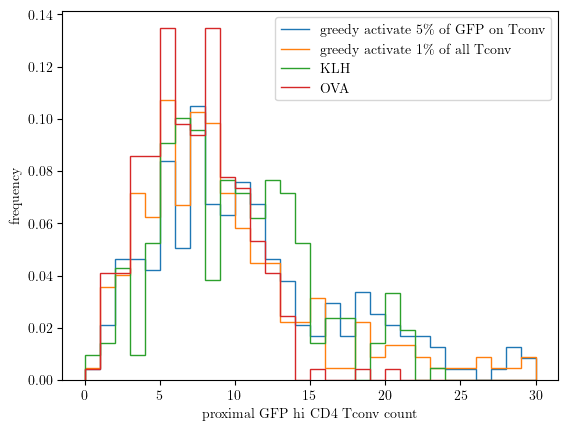

In [51]:
plt.stairs(prox_cont_gfp_on[5],np.arange(n_bins_loc+1),label='greedy activate 5\% of GFP on Tconv')
plt.stairs(prox_cont_all[6],np.arange(n_bins_loc+1),label='greedy activate 1\% of all Tconv')
for sample in ['1L2','1R2']:
    prox_dist=((exports[f'{sample}_Th_mAPC_dist'][exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh])<max_dist).sum(axis=0)
    plt.stairs(np.histogram(prox_dist,bins=np.arange(n_bins_loc+1),density=True)[0].reshape((1,-1))[0],np.arange(n_bins_loc+1),label=condition(sample))

plt.legend()
plt.xlabel('proximal GFP hi CD4 Tconv count')
plt.ylabel('frequency')

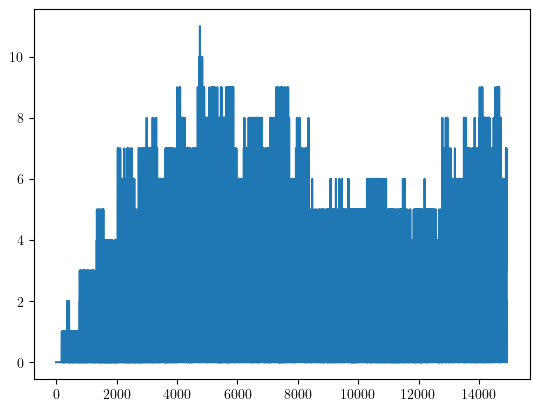

In [36]:
plt.plot(n_prox_arr*candidate_th_mask)

In [16]:
raw_mask=exports[f'{sample}_Th']['Intensity_Mean_GFP']>gfp_hi_thresh
raw_mask[idx_arr[:50]]=True

In [9]:
idx_arr

14922     5383
14921     4053
14920     6471
14919     4276
14918     7354
         ...  
4           20
3           19
2           18
1           17
0        14915
Name: Intensity_Mean_GFP, Length: 14923, dtype: int64

# Precursor frequency scan (bulk)

$N_{act}=f(t)pN_{tot}=f_{act}(t)N_{ln}(t)$  

rearranging  

$$p=\frac{f_{act}(t)N_{ln}(t)}{f(t)N_{tot}}$$


$f(t)$ is the fraction of precursors in the LN at time $t$  
this can be obtained from simulation, and we can vary the change in entry rate of cells      


$p$ is the precursor frequency  
this is what we want to estimate  


$N_{tot}$ is the total number of CD4 Tconv  
this is empirical (~2e7) 


$f_{act}(t)$ is the fraction of cells in the LN at time $t$  
this is an experimental measurement (~0.01) 


$N_{ln}(t)$ is the number of naive cells in the LN at time $t$  
this is hard to quantify, so we will vary it   
-we could measure this empirically  
-we could try to estimate this by migration dynamics, but it is unclear how the exit of naive cells change following inflammation  

Text(0.92, 0.15, 'physiological range')

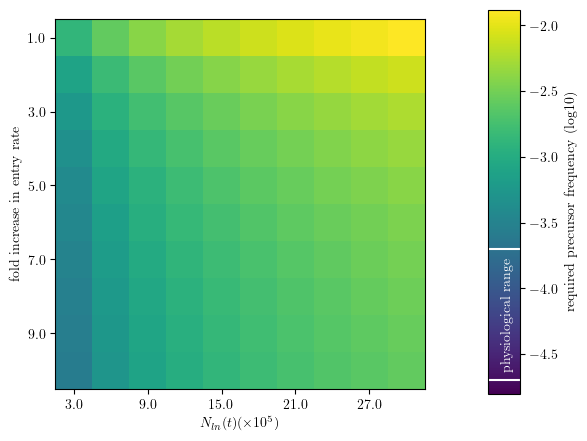

In [64]:
n_x=10
n_y=10
data_arr=np.zeros((n_x,n_y))
entry_fac_range=np.linspace(1,10,n_x)
ft_range=np.zeros_like(entry_fac_range)
for i,fac_e_i in enumerate(entry_fac_range):
    simulation=ln_dynamics()
    simulation.equilibrate()
    simulation.fac_e_i=fac_e_i
    simulation.ti=9999.
    ft_range[i]=simulation.evolve(48)[1]

Nlnt_range=np.linspace(3.e5,3.e6,n_y)
fig,ax=plt.subplots()
im=ax.imshow(np.log10(np.outer(1/ft_range,Nlnt_range)*0.01/2.e7),vmin=-4.8)
ax.set_xticks(np.arange(0,10,2))
ax.set_yticks(np.arange(0,10,2))
ax.set_yticklabels(entry_fac_range[::2])
ax.set_xticklabels(Nlnt_range[::2]/1e5)
ax.set_ylabel('fold increase in entry rate')
ax.set_xlabel(r'$N_{ln}(t) (\times 10^5$)')
cax=fig.add_axes((0.9,0.1,0.05,0.8))
cbar=fig.colorbar(im,cax=cax)
cbar.set_label('required precursor frequency (log10)')
cax.axhline(np.log10(2.e-5),c='w')
cax.axhline(np.log10(2.e-4),c='w')
fig.text(0.92,0.15,'physiological range',rotation=90,c='w')

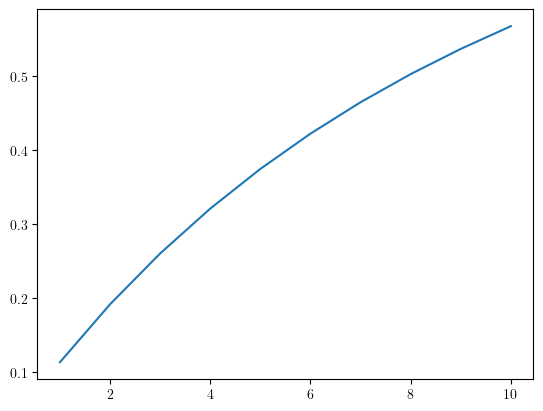

In [11]:
plt.plot(entry_fac_range,ft_range)

In [9]:
simulation=ln_dynamics()
simulation.equilibrate()
simulation.f

array([0.04 , 0.024, 0.024, 0.672])